# Synchronized lysis: quorum-triggered chemotherapy delivery

A synchronized lysis circuit (SLC, after Din et al. 2016) programs a
bacterial population to periodically self-destruct once it reaches a
threshold density, releasing a therapeutic payload each time it does.
This notebook builds one directly on top of two features already in the
package: the LuxI/AHL **quorum-sensing** module from
[`quorum_sensing_demo.ipynb`](quorum_sensing_demo.ipynb), and
**lysis-based delivery** (`Cell.lysis_targets` /
`Colony.enforce_survival_conditions`).

The circuit:

- The LuxI/AHL auto-induction module is reused verbatim from the
  quorum-sensing demo: each cell secretes AHL, which diffuses through the
  shared extracellular space and auto-induces its own synthesis, producing
  a density-dependent "quorum switch."
- The same lux promoter also drives the bacteriophage **φX174 lysis gene
  E**, so it turns on exactly when a GFP reporter would in the
  quorum-sensing demo. Once a cell's `phiX174_E` concentration crosses a
  threshold, a `Colony` survival condition kills it — modeling the
  irreversible commitment to lysis once enough lysis protein has
  accumulated.
- Every cell also **constitutively** expresses hemolysin E (`hlyE`), a
  pore-forming toxin used here as the chemotherapy payload. `hlyE` is
  never secreted while the cell is alive — it is delivered in one bulk
  dump into the extracellular `hlyE_field` only at the instant of lysis,
  via `lysis_targets`.
- Extracellular AHL is degraded by a **fast field-local reaction**
  (`Environment(reactions=...)`, the same reaction-diffusion mechanism as
  the Gray-Scott demo in `feature_tour.ipynb`). Without it, AHL released
  by one synchronized burst would simply linger and re-trigger lysis in
  the handful of survivors before they can regrow. With it, the shared
  signal clears quickly once the secreting population crashes, letting
  survivors restart the growth → quorum → lysis cycle — so the colony
  lyses **more than once** over the course of the simulation.


In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

from multicellular import Cell, Colony, Environment, Field, ReactionNetwork, Simulation
from multicellular.core.reactions import Reaction

os.makedirs("outputs", exist_ok=True)
plt.rcParams["figure.dpi"] = 100

## 1. The circuit: quorum sensing, lysis, and payload delivery

`ahl_synth` and `ahl_export` are the exact reactions from the
quorum-sensing demo — AHL auto-induction and its secretion into the
shared `AHL` field. `lysis_synth`/`lysis_deg` put `phiX174_E` under the
*same* lux promoter (`hl_params`), so its induction tracks AHL exactly
like the quorum-sensing demo's GFP did. `hlyE_synth`/`hlyE_deg` express
`hlyE_internal` constitutively (no AHL dependence — no `catalysts` at
all, just zeroth-order synthesis, mirroring the birth-death network in
`feature_tour.ipynb`).

`hlyE_internal` and its extracellular target `hlyE_field` are
deliberately different species names: `Cell.__init__` requires this
whenever `lysis_targets` is used, since `Colony.apply_chemical_fields`
mirrors a chemical field's value into cells non-depletingly, and reusing
the same name would let a cell's lysis re-inject mass that was never
actually removed from the field (see the README's
[Lysis-based delivery](../README.md#lysis-based-delivery) section).

`ahl_field_deg` is not a `Cell` reaction at all — it is a *field-local*
reaction, handed to `Environment(reactions=...)` so `Environment.react()`
degrades `AHL` at every grid voxel independently of any cell, at a rate
fast enough to clear a burst's residual signal well within one
growth-to-quorum cycle.

In [2]:
# Shared LuxI/AHL parameters (identical to quorum_sensing_demo.ipynb)
ALPHA, K_HALF, N_HILL, K_BASAL = 50, 0.5, 3, 0.05
K_SEC = 2.0
C = 1.0 / K_HALF**N_HILL
hl_params = {"alpha": ALPHA, "beta": K_BASAL, "C": C, "n": N_HILL}

# Lysis gene (phiX174 E): fast kinetics relative to growth, so that once a
# cell's local AHL crosses K_HALF, phiX174_E snaps to its new steady state
# (and the cell lyses) much faster than the colony can regrow around it --
# this is what makes the crash "synchronized" instead of a slow trickle.
K_LYS_DEG = 2.0
LYSIS_THRESHOLD = 0.8

# Constitutive hlyE (chemotherapy payload), delivered only by lysis
K_HLYE_SYNTH, K_HLYE_DEG = 0.3, 0.05

# Fast extracellular AHL degradation -- lets survivors' local AHL clear
# quickly after a burst, instead of re-triggering lysis before they regrow
K_AHL_DEG_EXTRACELLULAR = 0.04
AHL_DIFFUSIVITY = 5e-13
HLYE_DIFFUSIVITY = 1e-13  # hlyE is a much larger protein than AHL

ahl_synth  = Reaction({}, {"AHL_int": 1}, catalysts=["RNAP", "AHL"],
                      rate_law_type="hill_langmuir", rate_params=hl_params)
ahl_export = Reaction({"AHL_int": 1}, {}, exports={"AHL": 1},
                      rate_law_type="mass_action", rate_params={"k": K_SEC})
lysis_synth = Reaction({}, {"phiX174_E": 1}, catalysts=["RNAP", "AHL"],
                       rate_law_type="hill_langmuir", rate_params=hl_params)
lysis_deg   = Reaction({"phiX174_E": 1}, {}, rate_law_type="mass_action",
                       rate_params={"k": K_LYS_DEG})
hlyE_synth  = Reaction({}, {"hlyE_internal": 1}, rate_law_type="mass_action",
                       rate_params={"k": K_HLYE_SYNTH})
hlyE_deg    = Reaction({"hlyE_internal": 1}, {}, rate_law_type="mass_action",
                       rate_params={"k": K_HLYE_DEG})

slc_reactions = {
    "ahl_synth": ahl_synth, "ahl_export": ahl_export,
    "lysis_synth": lysis_synth, "lysis_deg": lysis_deg,
    "hlyE_synth": hlyE_synth, "hlyE_deg": hlyE_deg,
}

# Field-local reaction: fast extracellular AHL degradation, stepped by
# Environment.react() at every grid voxel (see feature_tour.ipynb section 9)
ahl_field_deg = Reaction({"AHL": 1}, {}, rate_law_type="mass_action",
                         rate_params={"k": K_AHL_DEG_EXTRACELLULAR})
env_reactions = ReactionNetwork("ahl_degradation", {"ahl_deg": ahl_field_deg})

SHAPE, BOUNDS = (15, 15), (60.0, 60.0)

def slc_env():
    """Environment with a diffusing+degrading AHL field, a constant RNAP
    field, and a diffusing hlyE field to receive the lysis payload."""
    return Environment(
        "Synchronized Lysis Demo", wall_map=np.zeros(SHAPE), size=BOUNDS,
        fields=[
            Field("AHL", np.zeros(SHAPE), is_chemical=True, diffuses=True,
                  diffusivity=AHL_DIFFUSIVITY),
            Field("RNAP", np.ones(SHAPE), is_chemical=True),
            Field("hlyE_field", np.zeros(SHAPE), diffuses=True,
                  diffusivity=HLYE_DIFFUSIVITY),
        ],
        reactions=env_reactions,
    )

## 2. Dose response: how sharp is the lysis trigger?

Both `AHL` (auto-induction) and `phiX174_E` (lysis) are driven by the same
Hill-Langmuir promoter, but `phiX174_E` decays about an order of
magnitude faster (`K_LYS_DEG` vs `K_GFP_DEG`-style degradation), so it
tracks the *instantaneous* extracellular AHL level almost immediately
rather than integrating it over time. Plotting its steady state,
`phiX174_E_ss(AHL) = K_BASAL * (1 + ALPHA*C*AHL**n) / (K_LYS_DEG * (1 + C*AHL**n))`,
against `LYSIS_THRESHOLD` shows the AHL level a cell's local environment
must sustain before it commits to lysis.

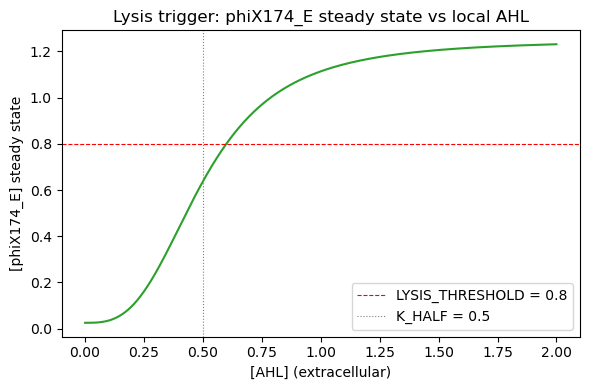

In [3]:
ahl_range = np.linspace(0.0, 2.0, 500)
lysis_ss = K_BASAL * (1 + ALPHA * C * ahl_range**N_HILL) / (K_LYS_DEG * (1 + C * ahl_range**N_HILL))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ahl_range, lysis_ss, color="tab:green")
ax.axhline(LYSIS_THRESHOLD, color="red", linestyle="--", linewidth=0.8,
           label=f"LYSIS_THRESHOLD = {LYSIS_THRESHOLD}")
ax.axvline(K_HALF, color="gray", linestyle=":", linewidth=0.8, label=f"K_HALF = {K_HALF}")
ax.set_xlabel("[AHL] (extracellular)")
ax.set_ylabel("[phiX174_E] steady state")
ax.set_title("Lysis trigger: phiX174_E steady state vs local AHL")
ax.legend()
fig.tight_layout()
plt.show()

## 3. Growing a colony through repeated lysis cycles

Two cells are seeded at low density, exactly as in the quorum-sensing
demo, and left to grow, divide, and sense their shared `AHL` field. Every
step, `Colony.enforce_survival_conditions` kills any cell whose
`phiX174_E` has crossed `LYSIS_THRESHOLD` and immediately delivers its
`hlyE_internal` payload into `hlyE_field` (see
[Lysis-based delivery](../README.md#lysis-based-delivery)) — never on an
out-of-bounds death, only on this survival-condition violation.

In [4]:
GROWTH_RATE = 0.04
DT, T_TOTAL = 0.25, 450.0

cells_slc = [
    Cell(
        id=i, position=[29.0 + i*2, 30.0], orientation=[1.0, 0.0], length=2.0,
        network=ReactionNetwork("synchronized_lysis", slc_reactions),
        growth_rate=GROWTH_RATE, rng=np.random.default_rng(i),
        lysis_targets={"hlyE_internal": "hlyE_field"},
    )
    for i in range(2)
]

colony = Colony(cells_slc, slc_env(), k=10.0, drag=1.0,
                 survival_conditions=[("phiX174_E", "<", LYSIS_THRESHOLD)])
sim = Simulation(colony, dt=DT, t_max=T_TOTAL)
df = sim.run(show_progress=False)

print(f"{df['cell_id'].nunique()} cells lived at some point over the simulation")

1646 cells lived at some point over the simulation


## 4. Population dynamics: quorum, crash, regrow, quorum again

Summing `alive` per recorded time gives the living population size. A
local peak followed by a drop of at least half (a "crash") is counted as
one synchronized lysis event; the cumulative `hlyE_field` mass (summed
over the grid) shows the payload released by each one.

In [5]:
n_alive = df.groupby("time")["alive"].sum()
ahl_mean = df.groupby("time")["AHL"].mean()
lysis_mean = df.groupby("time")["phiX174_E"].mean()
hlye_total = np.array([fields["hlyE_field"].sum() for _, fields in sim.field_history])
field_times = np.array([t for t, _ in sim.field_history])

# Count synchronized lysis events: a running local maximum followed by a
# drop to less than half its value (then a new running max resets the count)
events = []
running_max = n_alive.iloc[0]
running_max_t = n_alive.index[0]
triggered = False
for t, n in n_alive.items():
    if n > running_max:
        running_max, running_max_t = n, t
        triggered = False
    elif not triggered and n <= 0.5 * running_max and running_max >= 8:
        events.append((running_max_t, running_max, t, n))
        triggered = True

print(f"{len(events)} synchronized lysis event(s) detected:")
for peak_t, peak_n, trough_t, trough_n in events:
    print(f"  peak {peak_n:.0f} cells at t={peak_t:.1f}  ->  "
          f"crashes to {trough_n:.0f} cells by t={trough_t:.1f}")

2 synchronized lysis event(s) detected:
  peak 85 cells at t=89.8  ->  crashes to 41 cells by t=133.0
  peak 141 cells at t=281.5  ->  crashes to 70 cells by t=303.5


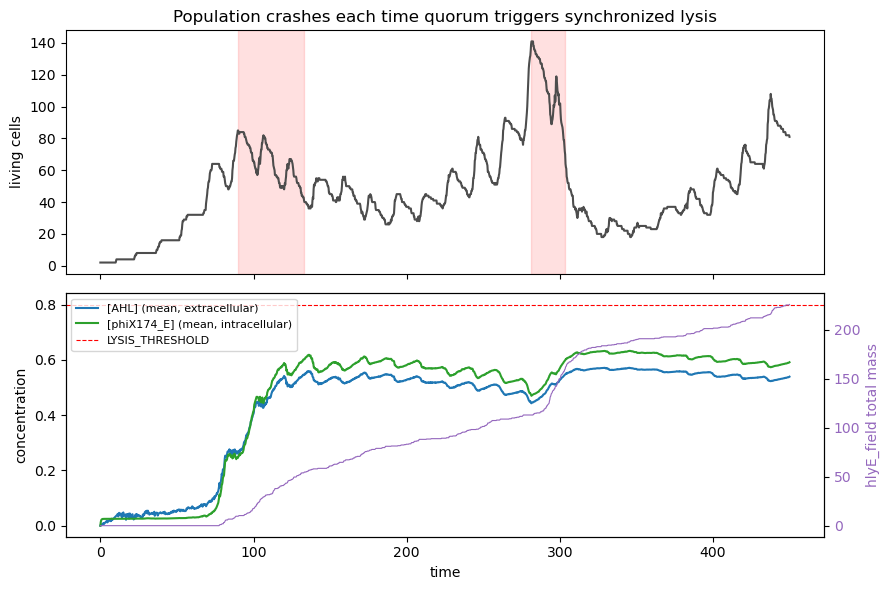

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.plot(n_alive.index, n_alive.values, color="0.3")
for peak_t, peak_n, trough_t, trough_n in events:
    ax1.axvspan(peak_t, trough_t, color="red", alpha=0.12)
ax1.set_ylabel("living cells")
ax1.set_title("Population crashes each time quorum triggers synchronized lysis")

ax2.plot(ahl_mean.index, ahl_mean.values, color="tab:blue", label="[AHL] (mean, extracellular)")
ax2.plot(lysis_mean.index, lysis_mean.values, color="tab:green", label="[phiX174_E] (mean, intracellular)")
ax2.axhline(LYSIS_THRESHOLD, color="red", linestyle="--", linewidth=0.8, label="LYSIS_THRESHOLD")
ax2b = ax2.twinx()
ax2b.plot(field_times, hlye_total, color="tab:purple", linewidth=0.8, label="hlyE_field (total mass)")
ax2b.set_ylabel("hlyE_field total mass", color="tab:purple")
ax2b.tick_params(axis="y", labelcolor="tab:purple")
ax2.set_xlabel("time")
ax2.set_ylabel("concentration")
ax2.legend(loc="upper left", fontsize=8)

fig.tight_layout()
plt.show()

## 5. AHL and hlyE fields: watching the payload accumulate in bursts

`AHL` rises with colony density, collapses right after each synchronized
lysis event (fast extracellular degradation, `K_AHL_DEG_EXTRACELLULAR`),
then rebuilds as survivors regrow. `hlyE_field`, in contrast, only ever
*increases* — each lysis event dumps another cohort's worth of `hlyE`
into it, so the video shows the chemotherapy payload accumulating in
discrete pulses rather than smoothly.

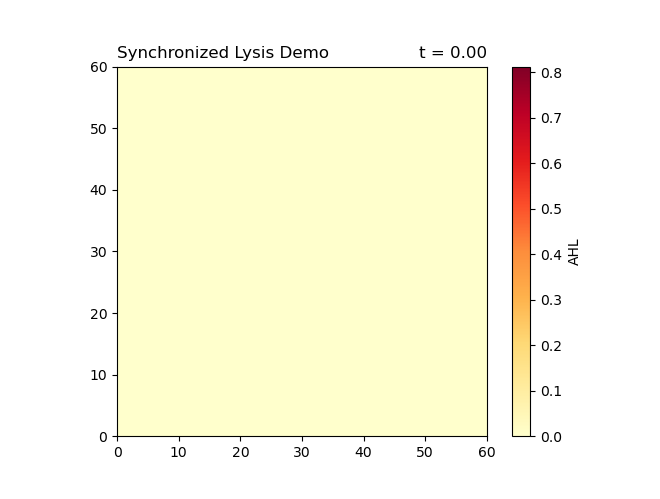

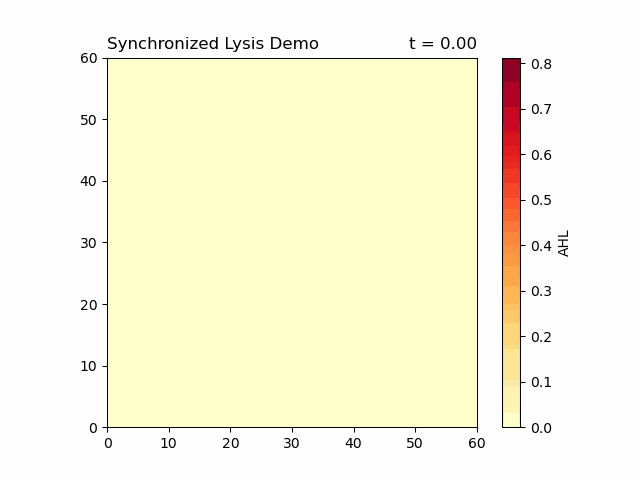

In [7]:
sim.visualize_field("AHL", cmap="YlOrRd", stride=10, interval=80,
                     save_path="outputs", filename="slc_ahl_field.gif", show_progress=False)
Image(filename="outputs/slc_ahl_field.gif")

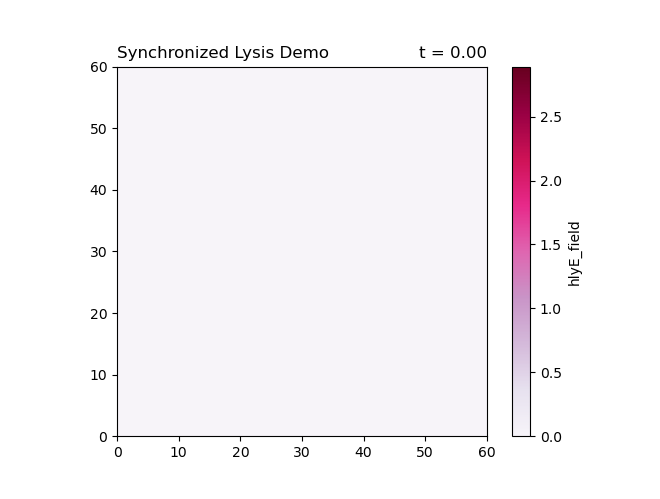

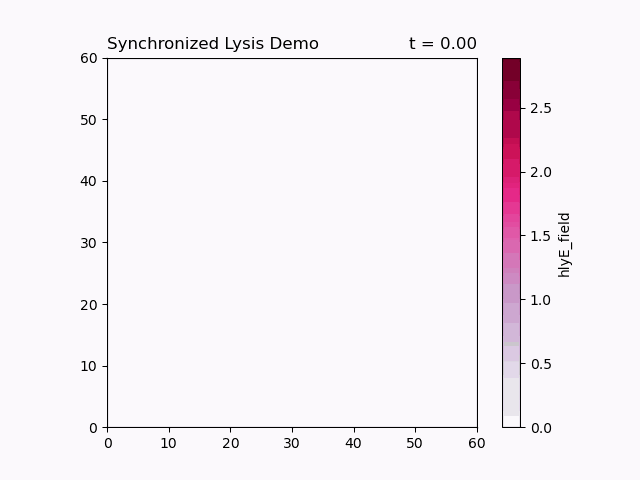

In [8]:
sim.visualize_field("hlyE_field", cmap="PuRd", stride=10, interval=80,
                     save_path="outputs", filename="slc_hlye_field.gif", show_progress=False)
Image(filename="outputs/slc_hlye_field.gif")

## 6. Colony animation: cells glow green before they lyse

`visualize_colony(green="phiX174_E", ...)` maps each living cell's lysis
protein concentration to the green channel only (no red or blue), so
cells brighten toward green as they approach `LYSIS_THRESHOLD` and simply
vanish from the frame the step they cross it and lyse.

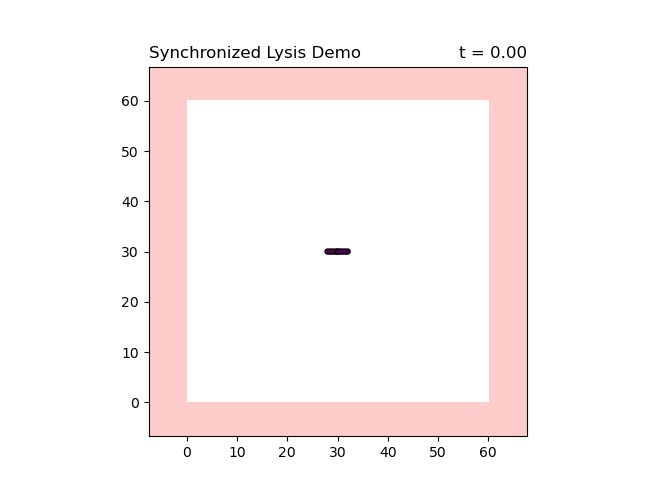

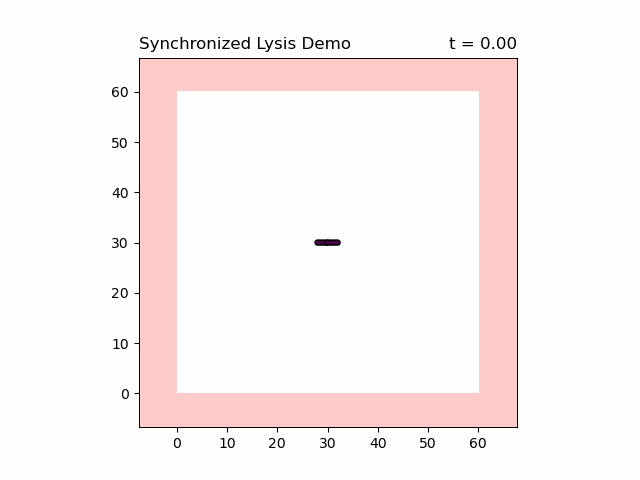

In [9]:
sim.visualize_colony(green="phiX174_E", stride=10, interval=80,
                      save_path="outputs", filename="slc_colony.gif", show_progress=False)
Image(filename="outputs/slc_colony.gif")